<a href="https://colab.research.google.com/github/steamulater/rap-snacks-v1/blob/main/boltz_validation_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Rap-Snacks Boltz Validation v2

Folds four sequence buckets through Boltz-2 to validate structure vs scrambled control.

| Bucket | n | Label |
|--------|---|-------|
| Concordance originals | 12 | `concordance` |
| Native-alanine originals | 12 | `native_ala` |
| Free-design MPNN (all passing/bar) | ~60 | `free_design` |
| Scrambled controls (5/bar) | 60 | `scrambled` |

**Expected result:** `scrambled` ≪ `concordance` ≈ `native_ala` < `free_design`

**Runtime:** ~2–3 hrs on A100 (all seqs × 5 models, scrambled × 1 model, `--no_kernels`)

---
## Cell 1 — Install

Run **once** per session. Auto-restarts the runtime after install to fix numpy binary incompatibility.  
After restart, **skip this cell** and start from Cell 2.

In [ ]:
import subprocess, sys

# Check if boltz is already installed (skip restart if so)
try:
    import boltz  # noqa: F401
    print('Boltz already installed — skip this cell and run from Cell 2.')
except ImportError:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', '--no-warn-conflicts', 'boltz'], check=True)
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'biopython'], check=True)
    print('Install complete. Restarting runtime to reload numpy (takes ~5 s)...')
    print('After restart: skip this cell, run from Cell 2 onward.')
    import time; time.sleep(3)
    import os; os.kill(os.getpid(), 9)

Install complete. Restarting runtime to reload numpy (takes ~5 s)...
After restart: skip this cell, run from Cell 2 onward.


---
## Cell 2 — Mount Drive + Check Inputs

In [2]:
from pathlib import Path
from google.colab import drive

drive.mount('/content/drive', force_remount=False)

DRIVE_ROOT    = Path('/content/drive/MyDrive/rap_snacks')
DRIVE_IN      = DRIVE_ROOT / 'inputs'
DRIVE_RES     = DRIVE_ROOT / 'results'
DRIVE_FIGS    = DRIVE_RES  / 'figures'
CONTENT       = Path('/content/scratch')

for p in [DRIVE_IN, DRIVE_RES, DRIVE_FIGS, CONTENT]:
    p.mkdir(parents=True, exist_ok=True)

DATA          = DRIVE_IN / 'data'
MPNN_FREE     = DRIVE_IN / 'outputs' / 'proteinmpnn_free' / 'filtered_results.csv'
SCRAMBLED     = DRIVE_IN / 'outputs' / 'scrambled'        / 'scrambled_results.csv'
BACKBONE_PDBS = DRIVE_IN / 'outputs' / 'proteinmpnn'      / 'pdbs'

checks = [
    DATA / 'aggregated_lines_v2_enriched.csv',
    DATA / 'phase2_candidates.csv',
    MPNN_FREE,
    SCRAMBLED,
    BACKBONE_PDBS,
]
all_ok = True
for p in checks:
    status = '✅' if p.exists() else '❌ MISSING'
    if not p.exists(): all_ok = False
    print(f'{status}  {p.relative_to(DRIVE_ROOT)}')
if all_ok:
    print('\nAll inputs present — ready to run.')
else:
    print('\n⚠️  Upload missing files to Drive before continuing.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅  inputs/data/aggregated_lines_v2_enriched.csv
✅  inputs/data/phase2_candidates.csv
✅  inputs/outputs/proteinmpnn_free/filtered_results.csv
✅  inputs/outputs/scrambled/scrambled_results.csv
✅  inputs/outputs/proteinmpnn/pdbs

All inputs present — ready to run.


---
## Cell 3 — Config

In [3]:
import json, random, shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

TOP_N       = 12
N_SCRAMBLES = 5     # scrambled seqs per bar
SEED        = 42
N_MODELS    = 5     # diffusion samples for concordance / native_ala / free_design
N_MODELS_SC = 1     # diffusion samples for scrambled (negative control only)

BOLTZ_IN    = CONTENT / 'boltz_inputs'            # concordance + native_ala + free_design
BOLTZ_IN_SC = CONTENT / 'boltz_inputs_scrambled'  # scrambled
BOLTZ_OUT   = CONTENT / 'boltz_outputs'
BOLTZ_OUT_SC= CONTENT / 'boltz_outputs_scrambled'

VALID_AA = set('ACDEFGHIKLMNPQRSTVWY')

print('Config loaded.')
print(f'  N_MODELS (main) = {N_MODELS}')
print(f'  N_MODELS (scrambled) = {N_MODELS_SC}')

Config loaded.
  N_MODELS (main) = 5
  N_MODELS (scrambled) = 1


---
## Cell 4 — Helpers

In [4]:
def hamming(a, b):
    return sum(x != y for x, y in zip(a, b))


def greedy_diverse(seqs, n=5):
    """Greedy max-min Hamming: pick n sequences maximally spread in sequence space."""
    selected = [0]
    while len(selected) < min(n, len(seqs)):
        best, best_dist = -1, -1
        for i in range(len(seqs)):
            if i in selected: continue
            min_dist = min(hamming(seqs[i], seqs[j]) for j in selected)
            if min_dist > best_dist:
                best, best_dist = i, min_dist
        selected.append(best)
    return selected


def write_boltz_yaml(name, sequence, out_dir):
    """Write a single-chain Boltz input YAML. msa: empty required for single-seq mode."""
    path = out_dir / f'{name}.yaml'
    path.write_text(
        f'version: 1\n'
        f'sequences:\n'
        f'  - protein:\n'
        f'      id: A\n'
        f'      sequence: {sequence}\n'
        f'      msa: empty\n'
    )
    return path


def parse_boltz_outputs(boltz_out_dir):
    """
    Parse Boltz output directory. Averages metrics across all diffusion models.
    Returns {name: {'plddt': float, 'ptm': float, 'confidence': float,
                    'plddt_std': float, 'n_models': int}}.

    Boltz nests as: out_dir/boltz_results_{input_name}/predictions/{seq_name}/
    We search recursively for the predictions dir.
    """
    results = {}
    preds_dirs = list(Path(boltz_out_dir).rglob('predictions'))
    if not preds_dirs:
        print(f'[WARN] No predictions dir found under {boltz_out_dir}')
        return results
    preds_dir = preds_dirs[0]

    for seq_dir in sorted(preds_dir.iterdir()):
        if not seq_dir.is_dir(): continue
        name = seq_dir.name
        conf_files  = sorted(seq_dir.glob('confidence_*.json'))
        plddt_files = sorted(seq_dir.glob('plddt_*.npz'))
        if not conf_files:
            continue
        plddt_means, ptms, confs = [], [], []
        for cf, pf in zip(conf_files, plddt_files):
            c = json.loads(cf.read_text())
            ptms.append(c.get('ptm', 0))
            confs.append(c.get('confidence_score', 0))
            arr = np.load(pf)
            key = list(arr.keys())[0]
            plddt_means.append(float(np.mean(arr[key])))
        results[name] = {
            'plddt':      float(np.mean(plddt_means)),
            'plddt_std':  float(np.std(plddt_means)),
            'ptm':        float(np.mean(ptms)),
            'confidence': float(np.mean(confs)),
            'n_models':   len(conf_files),
        }
    return results


def get_ca_atoms(pdb_path):
    from Bio.PDB import PDBParser
    parser = PDBParser(QUIET=True)
    st = parser.get_structure('s', str(pdb_path))
    return [r['CA'] for m in st for c in m for r in c if 'CA' in r]


def compute_rmsd(pdb_a, pdb_b):
    from Bio.PDB import Superimposer
    try:
        atoms_a = get_ca_atoms(pdb_a)
        atoms_b = get_ca_atoms(pdb_b)
        if len(atoms_a) != len(atoms_b) or not atoms_a:
            return None
        sup = Superimposer()
        sup.set_atoms(atoms_a, atoms_b)
        return round(float(sup.rms), 3)
    except Exception:
        return None


print('Helpers loaded.')

Helpers loaded.


---
## Cell 5 — Build Boltz Inputs

Loads all four buckets and writes one YAML per sequence.

In [5]:
BOLTZ_IN.mkdir(parents=True, exist_ok=True)
BOLTZ_IN_SC.mkdir(parents=True, exist_ok=True)

enriched   = pd.read_csv(DATA / 'aggregated_lines_v2_enriched.csv')
candidates = pd.read_csv(DATA / 'phase2_candidates.csv').head(TOP_N)
bar_ids    = list(candidates['bar_id'])
sub        = enriched[enriched['bar_id'].isin(bar_ids)].set_index('bar_id')

free_df    = pd.read_csv(MPNN_FREE)
sc_df      = pd.read_csv(SCRAMBLED)

meta_rows  = []

for bar_id in bar_ids:

    # concordance
    conc_seq = sub.loc[bar_id, 'fasta_seq_concordance']
    if pd.notna(conc_seq) and set(conc_seq.upper()) <= VALID_AA:
        name = f'{bar_id}_concordance'
        write_boltz_yaml(name, conc_seq, BOLTZ_IN)
        meta_rows.append((name, conc_seq, bar_id, 'concordance', ''))

    # native_ala
    na_seq = sub.loc[bar_id, 'fasta_seq_native_alanine']
    if pd.notna(na_seq) and set(na_seq.upper()) <= VALID_AA:
        name = f'{bar_id}_native_ala'
        write_boltz_yaml(name, na_seq, BOLTZ_IN)
        meta_rows.append((name, na_seq, bar_id, 'native_ala', ''))

    # free_design — ALL passing sequences, 5 models each
    grp = free_df[free_df['bar_id'] == bar_id].reset_index(drop=True)
    for i, row in grp.iterrows():
        if not set(str(row['sequence']).upper()) <= VALID_AA:
            continue
        name = f'{bar_id}_free_{i:03d}'
        write_boltz_yaml(name, row['sequence'], BOLTZ_IN)
        meta_rows.append((name, row['sequence'], bar_id, 'free_design',
                          f'esm_plddt={row["esm_plddt"]:.3f}'))

    # scrambled — 5 per bar, 1 model each
    sc_bar = sc_df[
        (sc_df['bar_id'] == bar_id) &
        (sc_df['source'] == 'scrambled_concordance') &
        (sc_df['seq'].notna())
    ].head(N_SCRAMBLES)
    for j, (_, sc_row) in enumerate(sc_bar.iterrows()):
        seq = str(sc_row['seq'])
        if set(seq.upper()) <= VALID_AA:
            name = f'{bar_id}_scrambled_{j:02d}'
            write_boltz_yaml(name, seq, BOLTZ_IN_SC)
            meta_rows.append((name, seq, bar_id, 'scrambled', ''))

meta = pd.DataFrame(meta_rows, columns=['name', 'sequence', 'bar_id', 'bucket', 'detail'])
print(f'Total sequences: {len(meta)}')
print(meta.groupby('bucket').size().rename('count').to_string())
print(f'Main inputs:      {len(list(BOLTZ_IN.glob("*.yaml")))} YAMLs (x{N_MODELS} models)')
print(f'Scrambled inputs: {len(list(BOLTZ_IN_SC.glob("*.yaml")))} YAMLs (x{N_MODELS_SC} model)')

Total sequences: 672
bucket
concordance     12
free_design    612
native_ala      12
scrambled       36
Main inputs:      636 YAMLs (x5 models)
Scrambled inputs: 36 YAMLs (x1 model)


---
## Cell 6 — Run Boltz

`--no_kernels` required on Colab (cuequivariance_ops_torch not available).  
Each pass backs up to Drive immediately — no data lost if runtime ends.

In [6]:
import subprocess  # needed after runtime restart (Cell 1 is skipped)

# Clear any stale output dirs
for d in [BOLTZ_OUT, BOLTZ_OUT_SC]:
    if d.exists(): shutil.rmtree(d)
BOLTZ_OUT.mkdir(parents=True, exist_ok=True)
BOLTZ_OUT_SC.mkdir(parents=True, exist_ok=True)

# Pass 1: concordance + native_ala + free_design  (N_MODELS diffusion samples)
cmd1 = ['boltz', 'predict', str(BOLTZ_IN),
        '--out_dir', str(BOLTZ_OUT),
        '--diffusion_samples', str(N_MODELS),
        '--output_format', 'pdb',
        '--no_kernels',
        '--override']
print('Pass 1/2:', ' '.join(cmd1))
r1 = subprocess.run(cmd1, capture_output=False, text=True)
if r1.returncode != 0:
    print(f'[ERROR] Pass 1 failed (exit {r1.returncode})')
else:
    print('Pass 1 complete. Backing up to Drive...')
    drive_out1 = DRIVE_RES / 'boltz_outputs'
    if drive_out1.exists(): shutil.rmtree(drive_out1)
    shutil.copytree(BOLTZ_OUT, drive_out1)
    print(f'Backed up → Drive: results/boltz_outputs/  ({sum(1 for _ in drive_out1.rglob("*.pdb"))} PDBs)')

# Pass 2: scrambled  (N_MODELS_SC diffusion samples)
cmd2 = ['boltz', 'predict', str(BOLTZ_IN_SC),
        '--out_dir', str(BOLTZ_OUT_SC),
        '--diffusion_samples', str(N_MODELS_SC),
        '--output_format', 'pdb',
        '--no_kernels',
        '--override']
print('Pass 2/2:', ' '.join(cmd2))
r2 = subprocess.run(cmd2, capture_output=False, text=True)
if r2.returncode != 0:
    print(f'[ERROR] Pass 2 failed (exit {r2.returncode})')
else:
    print('Pass 2 complete. Backing up to Drive...')
    drive_out2 = DRIVE_RES / 'boltz_outputs_scrambled'
    if drive_out2.exists(): shutil.rmtree(drive_out2)
    shutil.copytree(BOLTZ_OUT_SC, drive_out2)
    print(f'Backed up → Drive: results/boltz_outputs_scrambled/  ({sum(1 for _ in drive_out2.rglob("*.pdb"))} PDBs)')

Pass 1/2: boltz predict /content/scratch/boltz_inputs --out_dir /content/scratch/boltz_outputs --diffusion_samples 5 --output_format pdb --no_kernels --override
Pass 1 complete. Backing up to Drive...
Backed up → Drive: results/boltz_outputs/  (3180 PDBs)
Pass 2/2: boltz predict /content/scratch/boltz_inputs_scrambled --out_dir /content/scratch/boltz_outputs_scrambled --diffusion_samples 1 --output_format pdb --no_kernels --override
Pass 2 complete. Backing up to Drive...
Backed up → Drive: results/boltz_outputs_scrambled/  (36 PDBs)


---
## Cell 7 — Parse Results

Restores from Drive if scratch was wiped between sessions.

In [7]:
# Restore from Drive if scratch was wiped
if not BOLTZ_OUT.exists() or not any(BOLTZ_OUT.rglob('*.pdb')):
    print('Scratch empty — restoring from Drive...')
    drive_out1 = DRIVE_RES / 'boltz_outputs'
    drive_out2 = DRIVE_RES / 'boltz_outputs_scrambled'
    if drive_out1.exists():
        shutil.copytree(drive_out1, BOLTZ_OUT, dirs_exist_ok=True)
        print(f'  Restored boltz_outputs ({sum(1 for _ in BOLTZ_OUT.rglob("*.pdb"))} PDBs)')
    if drive_out2.exists():
        shutil.copytree(drive_out2, BOLTZ_OUT_SC, dirs_exist_ok=True)
        print(f'  Restored boltz_outputs_scrambled ({sum(1 for _ in BOLTZ_OUT_SC.rglob("*.pdb"))} PDBs)')
else:
    print(f'Scratch present: {sum(1 for _ in BOLTZ_OUT.rglob("*.pdb"))} PDBs in main output')

scores    = parse_boltz_outputs(BOLTZ_OUT)
scores_sc = parse_boltz_outputs(BOLTZ_OUT_SC)
scores.update(scores_sc)  # names are unique across buckets
print(f'\nParsed {len(scores)} predictions total')

meta['boltz_plddt']      = meta['name'].map(lambda n: scores.get(n, {}).get('plddt'))
meta['boltz_plddt_std']  = meta['name'].map(lambda n: scores.get(n, {}).get('plddt_std'))
meta['boltz_ptm']        = meta['name'].map(lambda n: scores.get(n, {}).get('ptm'))
meta['boltz_confidence'] = meta['name'].map(lambda n: scores.get(n, {}).get('confidence'))
meta['n_models']         = meta['name'].map(lambda n: scores.get(n, {}).get('n_models'))

results_path = CONTENT / 'boltz_validation_results.csv'
meta.to_csv(results_path, index=False)
shutil.copy2(results_path, DRIVE_RES / 'boltz_validation_results.csv')
print('Saved → Drive: results/boltz_validation_results.csv')

print('\n--- Boltz pLDDT by bucket ---')
for bucket, grp in meta.groupby('bucket'):
    vals = grp['boltz_plddt'].dropna()
    if vals.empty:
        print(f'  {bucket:15s}  no data')
        continue
    n_mod = int(grp['n_models'].dropna().iloc[0]) if grp['n_models'].notna().any() else '?'
    print(f'  {bucket:15s}  n={len(vals):3d}  mean={vals.mean():.3f}  '
          f'sd={vals.std():.3f}  min={vals.min():.3f}  max={vals.max():.3f}  [{n_mod} models/seq]')

Scratch present: 3180 PDBs in main output

Parsed 672 predictions total
Saved → Drive: results/boltz_validation_results.csv

--- Boltz pLDDT by bucket ---
  concordance      n= 12  mean=0.441  sd=0.069  min=0.338  max=0.590  [5 models/seq]
  free_design      n=612  mean=0.643  sd=0.173  min=0.330  max=0.960  [5 models/seq]
  native_ala       n= 12  mean=0.543  sd=0.107  min=0.362  max=0.689  [5 models/seq]
  scrambled        n= 36  mean=0.426  sd=0.068  min=0.335  max=0.615  [1 models/seq]


---
## Cell 8 — pLDDT Figures

Fig A: strip plot per bar (all buckets overlaid).  
Fig B: violin per bucket (distribution summary).

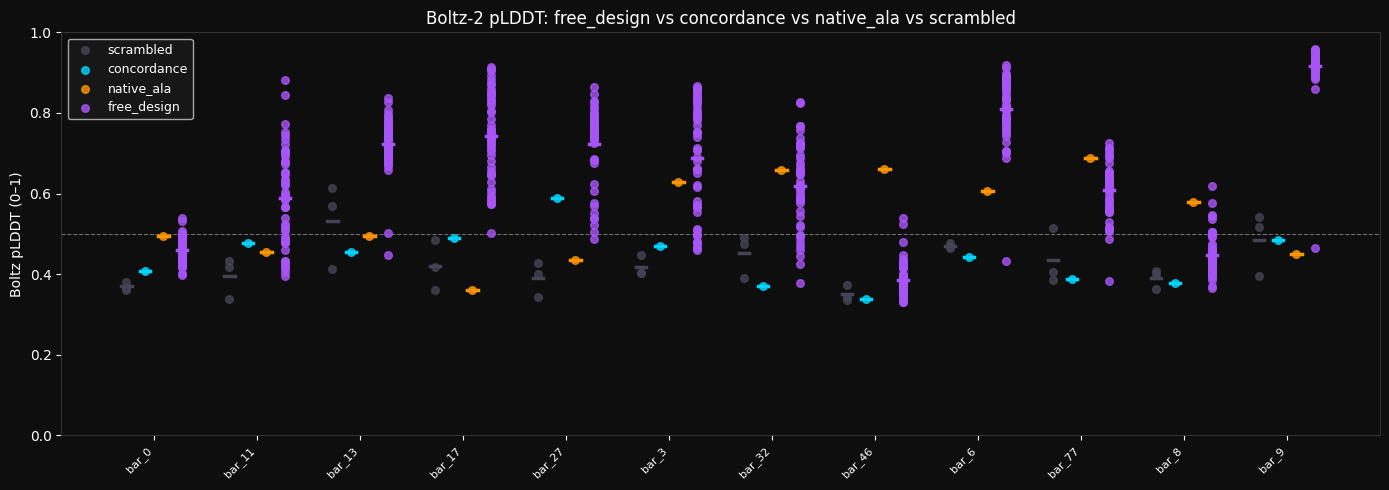

Fig A saved → Drive: results/figures/fig_boltz_per_bar.png


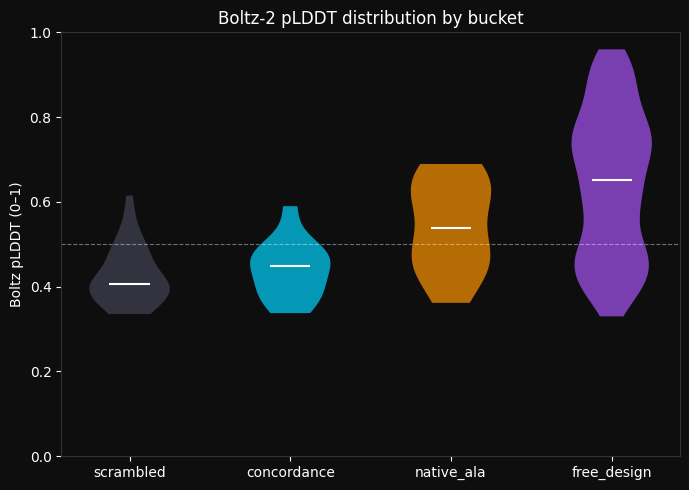

Fig B saved → Drive: results/figures/fig_boltz_violin.png


In [8]:
DARK_BG = '#0e0e0e'
COLORS  = {
    'concordance': '#00d4ff',
    'native_ala':  '#ff9500',
    'free_design': '#a855f7',
    'scrambled':   '#444455',
}
ORDER = ['scrambled', 'concordance', 'native_ala', 'free_design']

# ── Fig A: strip plot per bar ──────────────────────────────────────────────
bar_ids_sorted = sorted(meta['bar_id'].unique())
n_bars  = len(bar_ids_sorted)
n_buck  = len(ORDER)
width   = 0.18
offsets = np.linspace(-(n_buck-1)*width/2, (n_buck-1)*width/2, n_buck)

fig, ax = plt.subplots(figsize=(14, 5), facecolor=DARK_BG)
ax.set_facecolor(DARK_BG)
plotted = set()

for bi, bar_id in enumerate(bar_ids_sorted):
    for oi, bucket in enumerate(ORDER):
        vals = meta[(meta['bar_id']==bar_id) & (meta['bucket']==bucket)]['boltz_plddt'].dropna()
        if vals.empty: continue
        x = bi + offsets[oi]
        label = bucket if bucket not in plotted else ''
        ax.scatter([x]*len(vals), vals, color=COLORS[bucket], s=30, alpha=0.8,
                   label=label, zorder=3)
        ax.plot([x-0.05, x+0.05], [vals.mean(), vals.mean()],
                color=COLORS[bucket], linewidth=2.5, zorder=4)
        plotted.add(bucket)

ax.axhline(0.5, color='white', linestyle='--', linewidth=0.8, alpha=0.4)
ax.set_xticks(range(n_bars))
ax.set_xticklabels(bar_ids_sorted, rotation=45, ha='right', fontsize=8, color='white')
ax.set_ylabel('Boltz pLDDT (0–1)', color='white')
ax.set_ylim(0, 1)
ax.set_title('Boltz-2 pLDDT: free_design vs concordance vs native_ala vs scrambled',
             color='white', fontsize=12)
ax.tick_params(colors='white')
for spine in ax.spines.values(): spine.set_edgecolor('#333333')
handles, labels = ax.get_legend_handles_labels()
seen = {}
for h, l in zip(handles, labels):
    if l and l not in seen: seen[l] = h
ax.legend(seen.values(), seen.keys(), facecolor='#1a1a1a',
          labelcolor='white', framealpha=0.8, fontsize=9)
plt.tight_layout()
fig_a = CONTENT / 'fig_boltz_per_bar.png'
plt.savefig(fig_a, dpi=150, facecolor=DARK_BG)
shutil.copy2(fig_a, DRIVE_FIGS / 'fig_boltz_per_bar.png')
plt.show()
print('Fig A saved → Drive: results/figures/fig_boltz_per_bar.png')

# ── Fig B: violin per bucket ───────────────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(7, 5), facecolor=DARK_BG)
ax2.set_facecolor(DARK_BG)
data_by_bucket = [meta[meta['bucket']==b]['boltz_plddt'].dropna().values for b in ORDER]
valid_pairs = [(b, d) for b, d in zip(ORDER, data_by_bucket) if len(d) > 1]
if valid_pairs:
    parts = ax2.violinplot([d for _, d in valid_pairs],
                           positions=range(len(valid_pairs)),
                           showmedians=True, showextrema=False)
    for pc, (bucket, _) in zip(parts['bodies'], valid_pairs):
        pc.set_facecolor(COLORS[bucket]); pc.set_alpha(0.7)
    parts['cmedians'].set_color('white')
    ax2.set_xticks(range(len(valid_pairs)))
    ax2.set_xticklabels([b for b, _ in valid_pairs], color='white', fontsize=10)
ax2.set_ylabel('Boltz pLDDT (0–1)', color='white')
ax2.set_ylim(0, 1)
ax2.set_title('Boltz-2 pLDDT distribution by bucket', color='white', fontsize=12)
ax2.tick_params(colors='white')
for spine in ax2.spines.values(): spine.set_edgecolor('#333333')
ax2.axhline(0.5, color='white', linestyle='--', linewidth=0.8, alpha=0.4)
plt.tight_layout()
fig_b = CONTENT / 'fig_boltz_violin.png'
plt.savefig(fig_b, dpi=150, facecolor=DARK_BG)
shutil.copy2(fig_b, DRIVE_FIGS / 'fig_boltz_violin.png')
plt.show()
print('Fig B saved → Drive: results/figures/fig_boltz_violin.png')

---
## Cell 9 — RMSD Analysis

- RMSD of each folded sequence vs the concordance backbone (CA atoms only)
- Pairwise RMSD between all free_design structures per bar

**Requires:** `inputs/outputs/proteinmpnn/pdbs/` on Drive (12 chain-fixed backbone PDBs)

In [9]:
# Find the Boltz predictions directory (Boltz nests: out_dir/boltz_results_*/predictions/)
preds_dirs = list(BOLTZ_OUT.rglob('predictions'))
if not preds_dirs:
    raise RuntimeError(f'No predictions dir found under {BOLTZ_OUT}. Run Cell 6 or restore from Drive.')
preds_dir = preds_dirs[0]
print(f'Predictions dir: {preds_dir}')

rmsd_rows = []

for bar_id in sorted(meta['bar_id'].unique()):
    backbone_pdb = BACKBONE_PDBS / f'{bar_id}.pdb'
    if not backbone_pdb.exists():
        print(f'  [SKIP] {bar_id} — no backbone PDB on Drive')
        continue

    bar_seqs = meta[meta['bar_id'] == bar_id]
    free_pdbs = []

    for _, row in bar_seqs.iterrows():
        seq_dir  = preds_dir / row['name']
        pdb_list = sorted(seq_dir.glob('*.pdb')) if seq_dir.exists() else []
        if not pdb_list: continue
        seq_pdb = pdb_list[0]  # best model (model_0)
        rmsd = compute_rmsd(backbone_pdb, seq_pdb)
        rmsd_rows.append({'name':            row['name'],
                          'bar_id':          bar_id,
                          'bucket':          row['bucket'],
                          'rmsd_vs_backbone': rmsd})
        if row['bucket'] == 'free_design':
            free_pdbs.append((row['name'], seq_pdb))

    # Pairwise RMSD between free_design structures within the bar
    for i in range(len(free_pdbs)):
        for j in range(i+1, len(free_pdbs)):
            name_i, pdb_i = free_pdbs[i]
            name_j, pdb_j = free_pdbs[j]
            rmsd = compute_rmsd(pdb_i, pdb_j)
            rmsd_rows.append({'name':            f'{name_i}_vs_{name_j}',
                              'bar_id':          bar_id,
                              'bucket':          'free_pairwise',
                              'rmsd_vs_backbone': rmsd})

rmsd_df = pd.DataFrame(rmsd_rows)
rmsd_path = CONTENT / 'boltz_rmsd.csv'
rmsd_df.to_csv(rmsd_path, index=False)
shutil.copy2(rmsd_path, DRIVE_RES / 'boltz_rmsd.csv')
print('Saved → Drive: results/boltz_rmsd.csv')

print('\n--- RMSD vs concordance backbone ---')
for bucket, grp in rmsd_df[rmsd_df['bucket'] != 'free_pairwise'].groupby('bucket'):
    vals = grp['rmsd_vs_backbone'].dropna()
    if vals.empty: continue
    print(f'  {bucket:15s}  n={len(vals):3d}  mean={vals.mean():.2f}Å  '
          f'sd={vals.std():.2f}  min={vals.min():.2f}  max={vals.max():.2f}')

pw = rmsd_df[rmsd_df['bucket'] == 'free_pairwise']['rmsd_vs_backbone'].dropna()
if not pw.empty:
    print(f'  free_pairwise    n={len(pw):3d}  mean={pw.mean():.2f}Å  '
          f'sd={pw.std():.2f}  min={pw.min():.2f}  max={pw.max():.2f}')

Predictions dir: /content/scratch/boltz_outputs/boltz_results_boltz_inputs/predictions
Saved → Drive: results/boltz_rmsd.csv

--- RMSD vs concordance backbone ---
  concordance      n= 12  mean=9.58Å  sd=3.76  min=3.44  max=15.18
  free_design      n=612  mean=7.13Å  sd=5.11  min=0.35  max=17.56
  native_ala       n= 12  mean=16.90Å  sd=6.06  min=11.99  max=33.40
  free_pairwise    n=15300  mean=7.57Å  sd=4.65  min=0.35  max=18.35


---
## Cell 10 — RMSD Figures

Fig C: violin — RMSD vs backbone by bucket.  
Fig D: per-bar free_design RMSD vs backbone.  
Fig E: pairwise RMSD histogram (structural diversity of free_design).

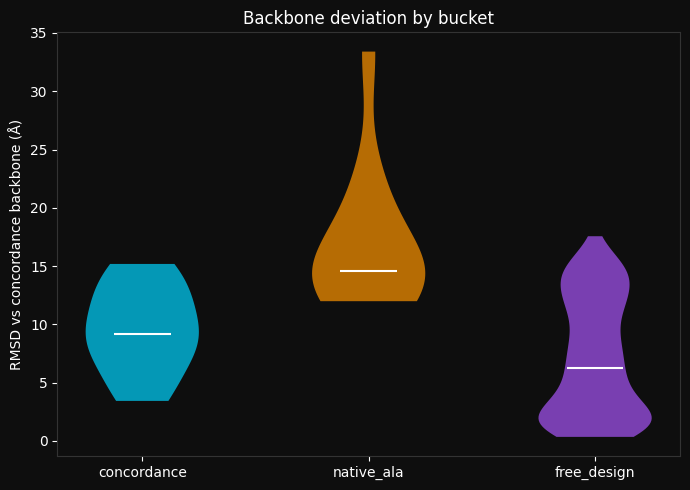

Fig C saved → Drive: results/figures/fig_rmsd_violin.png


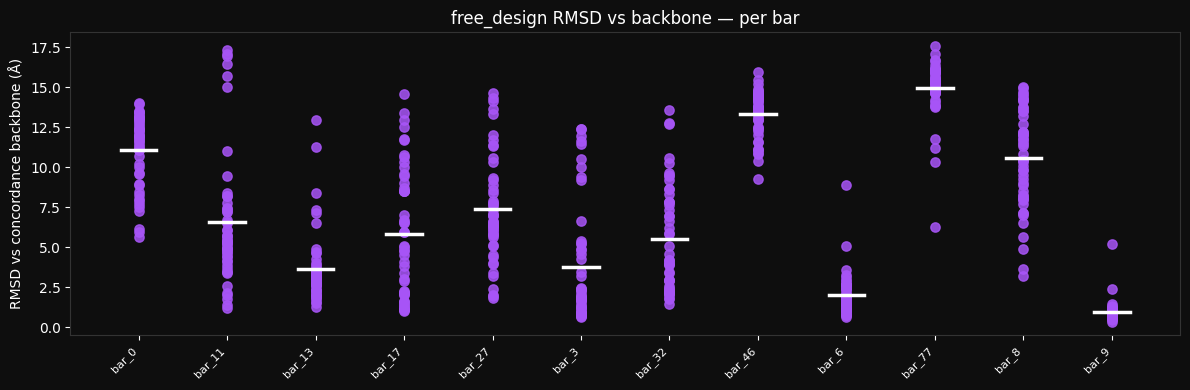

Fig D saved → Drive: results/figures/fig_rmsd_per_bar.png


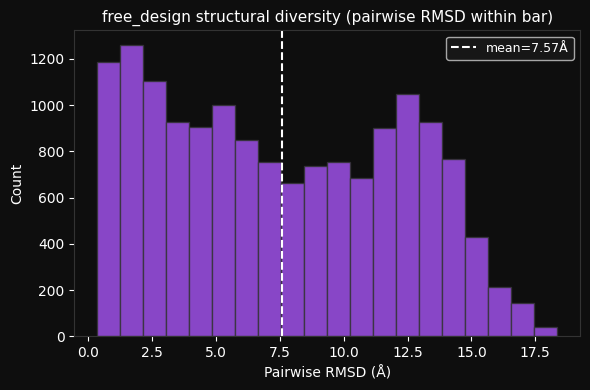

Fig E saved → Drive: results/figures/fig_rmsd_pairwise.png


In [10]:
RMSD_COLORS = {'concordance': '#00d4ff', 'native_ala': '#ff9500',
               'free_design': '#a855f7', 'scrambled':  '#444455'}
RMSD_ORDER  = ['concordance', 'native_ala', 'free_design', 'scrambled']

vs_bb = rmsd_df[rmsd_df['bucket'] != 'free_pairwise']

# ── Fig C: violin — RMSD vs backbone by bucket ────────────────────────────
fig3, ax3 = plt.subplots(figsize=(7, 5), facecolor=DARK_BG)
ax3.set_facecolor(DARK_BG)
valid = [(b, vs_bb[vs_bb['bucket']==b]['rmsd_vs_backbone'].dropna().values)
         for b in RMSD_ORDER if b in vs_bb['bucket'].values]
valid = [(b, d) for b, d in valid if len(d) > 1]
if valid:
    parts3 = ax3.violinplot([d for _, d in valid], positions=range(len(valid)),
                             showmedians=True, showextrema=False)
    for pc, (b, _) in zip(parts3['bodies'], valid):
        pc.set_facecolor(RMSD_COLORS.get(b, '#888')); pc.set_alpha(0.7)
    parts3['cmedians'].set_color('white')
    ax3.set_xticks(range(len(valid)))
    ax3.set_xticklabels([b for b, _ in valid], color='white', fontsize=10)
ax3.set_ylabel('RMSD vs concordance backbone (Å)', color='white')
ax3.set_title('Backbone deviation by bucket', color='white', fontsize=12)
ax3.tick_params(colors='white')
for s in ax3.spines.values(): s.set_edgecolor('#333')
plt.tight_layout()
fig_c = CONTENT / 'fig_rmsd_violin.png'
plt.savefig(fig_c, dpi=150, facecolor=DARK_BG)
shutil.copy2(fig_c, DRIVE_FIGS / 'fig_rmsd_violin.png')
plt.show()
print('Fig C saved → Drive: results/figures/fig_rmsd_violin.png')

# ── Fig D: per-bar free_design RMSD vs backbone ───────────────────────────
free_rmsd = vs_bb[vs_bb['bucket'] == 'free_design']
bar_ids_s = sorted(free_rmsd['bar_id'].unique())
fig4, ax4 = plt.subplots(figsize=(12, 4), facecolor=DARK_BG)
ax4.set_facecolor(DARK_BG)
for bi, bar_id in enumerate(bar_ids_s):
    vals = free_rmsd[free_rmsd['bar_id']==bar_id]['rmsd_vs_backbone'].dropna()
    ax4.scatter([bi]*len(vals), vals, color='#a855f7', s=45, alpha=0.85, zorder=3)
    if not vals.empty:
        ax4.plot([bi-0.2, bi+0.2], [vals.mean(), vals.mean()],
                 color='white', linewidth=2.5, zorder=4)
ax4.set_xticks(range(len(bar_ids_s)))
ax4.set_xticklabels(bar_ids_s, rotation=45, ha='right', fontsize=8, color='white')
ax4.set_ylabel('RMSD vs concordance backbone (Å)', color='white')
ax4.set_title('free_design RMSD vs backbone — per bar', color='white', fontsize=12)
ax4.tick_params(colors='white')
for s in ax4.spines.values(): s.set_edgecolor('#333')
plt.tight_layout()
fig_d = CONTENT / 'fig_rmsd_per_bar.png'
plt.savefig(fig_d, dpi=150, facecolor=DARK_BG)
shutil.copy2(fig_d, DRIVE_FIGS / 'fig_rmsd_per_bar.png')
plt.show()
print('Fig D saved → Drive: results/figures/fig_rmsd_per_bar.png')

# ── Fig E: pairwise RMSD histogram ────────────────────────────────────────
pw_vals = rmsd_df[rmsd_df['bucket']=='free_pairwise']['rmsd_vs_backbone'].dropna()
if not pw_vals.empty:
    fig5, ax5 = plt.subplots(figsize=(6, 4), facecolor=DARK_BG)
    ax5.set_facecolor(DARK_BG)
    ax5.hist(pw_vals, bins=20, color='#a855f7', alpha=0.8, edgecolor='#333')
    ax5.axvline(pw_vals.mean(), color='white', linestyle='--', linewidth=1.5,
                label=f'mean={pw_vals.mean():.2f}Å')
    ax5.set_xlabel('Pairwise RMSD (Å)', color='white')
    ax5.set_ylabel('Count', color='white')
    ax5.set_title('free_design structural diversity (pairwise RMSD within bar)',
                  color='white', fontsize=11)
    ax5.tick_params(colors='white')
    for s in ax5.spines.values(): s.set_edgecolor('#333')
    ax5.legend(facecolor='#1a1a1a', labelcolor='white', fontsize=9)
    plt.tight_layout()
    fig_e = CONTENT / 'fig_rmsd_pairwise.png'
    plt.savefig(fig_e, dpi=150, facecolor=DARK_BG)
    shutil.copy2(fig_e, DRIVE_FIGS / 'fig_rmsd_pairwise.png')
    plt.show()
    print('Fig E saved → Drive: results/figures/fig_rmsd_pairwise.png')
else:
    print('No pairwise RMSD data — skipping Fig E')

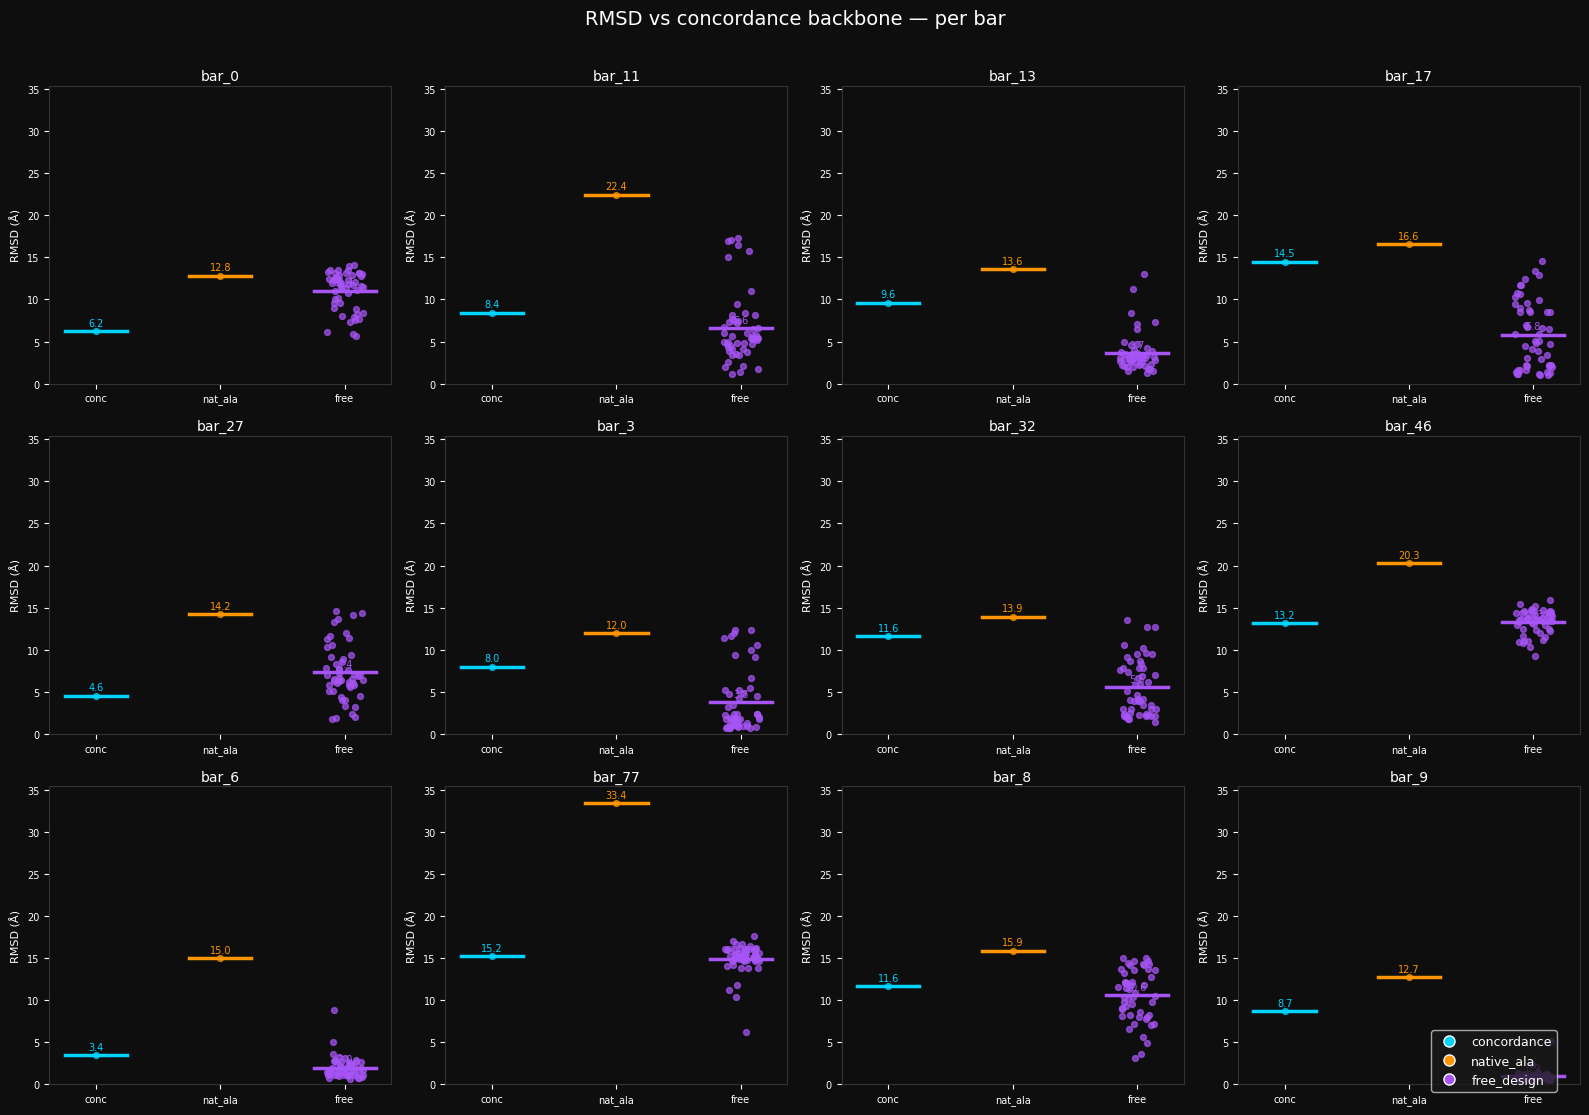

Saved → Drive: results/figures/fig_rmsd_per_bar_grid.png


In [11]:
  # ── Per-bar RMSD strip grid (3×4) ─────────────────────────────────────────
  DARK_BG = '#0e0e0e'
  COLORS  = {'concordance': '#00d4ff', 'native_ala': '#ff9500',
             'free_design': '#a855f7', 'scrambled':  '#666677'}
  ORDER   = ['concordance', 'native_ala', 'free_design']

  vs_bb     = rmsd_df[rmsd_df['bucket'].isin(ORDER)]
  bar_ids_s = sorted(vs_bb['bar_id'].unique())
  n_bars    = len(bar_ids_s)
  ncols, nrows = 4, 3

  fig, axes = plt.subplots(nrows, ncols, figsize=(16, 11), facecolor=DARK_BG)
  fig.suptitle('RMSD vs concordance backbone — per bar', color='white', fontsize=14, y=1.01)
  axes_flat = axes.flatten()

  for ax in axes_flat:
      ax.set_facecolor(DARK_BG)
      for s in ax.spines.values(): s.set_edgecolor('#333')

  for i, bar_id in enumerate(bar_ids_s):
      ax = axes_flat[i]
      bar_data = vs_bb[vs_bb['bar_id'] == bar_id]

      for xi, bucket in enumerate(ORDER):
          vals = bar_data[bar_data['bucket'] == bucket]['rmsd_vs_backbone'].dropna()
          if vals.empty: continue
          color = COLORS[bucket]

          # jitter x for free_design (many points), no jitter for single points
          if bucket == 'free_design':
              jitter = (np.random.rand(len(vals)) - 0.5) * 0.3
          else:
              jitter = np.zeros(len(vals))

          ax.scatter(xi + jitter, vals, color=color, s=18, alpha=0.7, zorder=3)
          ax.plot([xi - 0.25, xi + 0.25], [vals.mean(), vals.mean()],
                  color=color, linewidth=2.5, zorder=4)
          ax.text(xi, vals.mean() + 0.4, f'{vals.mean():.1f}',
                  ha='center', va='bottom', color=color, fontsize=7)

      ax.set_title(bar_id, color='white', fontsize=10, pad=4)
      ax.set_xticks(range(len(ORDER)))
      ax.set_xticklabels(['conc', 'nat_ala', 'free'], color='white', fontsize=8)
      ax.set_ylabel('RMSD (Å)', color='white', fontsize=8)
      ax.tick_params(colors='white', labelsize=7)
      ax.set_ylim(0, max(vs_bb['rmsd_vs_backbone'].max() + 2, 20))

  # hide any unused subplots
  for j in range(n_bars, len(axes_flat)):
      axes_flat[j].set_visible(False)

  # legend
  from matplotlib.lines import Line2D
  legend_elements = [Line2D([0], [0], marker='o', color='w', markerfacecolor=COLORS[b],
                            markersize=8, label=b, linestyle='None') for b in ORDER]
  fig.legend(handles=legend_elements, loc='lower right', facecolor='#1a1a1a',
             labelcolor='white', fontsize=9, framealpha=0.8,
             bbox_to_anchor=(0.98, 0.02))

  plt.tight_layout()
  fig_grid = Path('/content/scratch') / 'fig_rmsd_per_bar_grid.png'
  plt.savefig(fig_grid, dpi=150, facecolor=DARK_BG, bbox_inches='tight')
  import shutil
  shutil.copy2(fig_grid, Path('/content/drive/MyDrive/rap_snacks/results/figures') / 'fig_rmsd_per_bar_grid.png')
  plt.show()
  print('Saved → Drive: results/figures/fig_rmsd_per_bar_grid.png')